In [1]:
import numpy as np
import jax.numpy as jnp
import jax
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt

from parsimonious_ensembles.optimize_weights import multiplicative_gradient


/Users/levans/venvs/parsimonious_ensembles/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set Plotting Info

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use(f"../my_style.mplstyle") # Use stylefile defined
plt.style.use("seaborn-v0_8-colorblind") # Use colorscheme from colorblind seaborn
mpl.rcParams['text.usetex'] = True  # Uncomment for latex font in plots
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color'] # Save color list for reference


# Generate Data

### Ground Truth Distribution: 
$\pi(x) = \mathcal{N}(x;0, 1)$
### Data: 
$y = x + \epsilon, \epsilon \sim \mathcal{N}(0, \verb|noise_std_dev|^2),$ 
### i.e., 
$p(y|x) = \mathcal{N}(y;x, \verb|noise_std_dev|^2)$ 

$y_i \sim p(y) = \int p(y|x) \pi(x) dx = \mathcal{N}(0, 1 + \verb|noise_std_dev|^2)$ 

#### We can analyticaly compute the marginal $p(y)$ because $p(y|x)$ and $\pi(x)$ are Gaussian

In [3]:
# Parameters for dataset
num_data = 100000
num_nodes = 100
noise_std_dev = 1.0

In [4]:
# Generate noisy data
noiseless_data = jax.random.normal(jax.random.PRNGKey(43), shape=(num_data,))
noise = noise_std_dev*jax.random.normal(jax.random.PRNGKey(49), shape=noiseless_data.shape)
data = noiseless_data + noise

# Plot Noiseless and Noisy Data

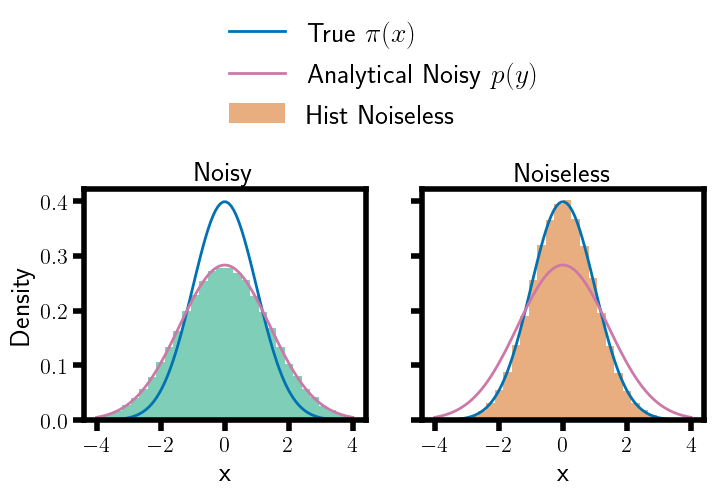

In [5]:
def gaussian(x, mean, var): 
    return (2*jnp.pi*var)**(0.5)*jnp.exp(-(x - mean)**2 / (2*var))

# compute pdf output on a 1d grid
xgrid = jnp.linspace(-4, 4, 100)
dx = xgrid[1] - xgrid[0]
    
# normalize output to integrate to 1 on the grid 
p = gaussian(xgrid, 0, 1)
p /= dx*p.sum() 

# check gaussian formula: in this case, we have an analytical formula for the noisy observed density
q = gaussian(xgrid, 0, 1 + noise_std_dev**2)
q /=dx*q.sum()

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)
nbins = 30
for ax in axes:
    ax.plot(xgrid, p, label='True $\\pi(x)$', c='C0')
    ax.plot(xgrid, q, label='Analytical Noisy $p(y)$', c='C3')

axes[0].hist(data, bins=nbins, range=(-4, 4), density=True, 
             alpha=0.5, color="C1", label='Hist Noisy')
axes[0].set_xticks([-4, -2, 0, 2, 4])
axes[1].hist(noiseless_data, bins=nbins, range=(-4, 4), 
             color="C2", density=True, alpha=0.5, label='Hist Noiseless')
axes[1].set_xticks([-4, -2, 0, 2, 4])
plt.legend(loc = 'lower center', bbox_to_anchor = (0, 1.0, 1, 1),
           bbox_transform = plt.gcf().transFigure)
for ax in axes:
    ax.set_xlabel('x')
axes[0].set_title('Noisy')
axes[1].set_title('Noiseless')
axes[0].set_ylabel('Density')
plt.show()


# Estimate Source Distribution

### Choose "nodes"/"structures" and evaluate the log-likelihood

In [6]:
# Choosing nodes: for now, just picking evenly spaced ones
nodes = np.linspace(-4, 4, num_nodes)
inds = jnp.array([1,2])
num_nodes = nodes.shape[0]
true_weights = gaussian(nodes, 0, 1)
true_weights /= true_weights.sum() 

# Choosing initial weights: for now, just constant weights
log_weights_init = np.log(np.ones_like(nodes)/num_nodes)

# Compute log likelihood matrix
log_likelihood = -1*(data[:, np.newaxis] - nodes[np.newaxis, :])**2 / (2*noise_std_dev**2)


## Optimize weights
### Here, we use the default tolerance for stopping

In [7]:
# Using all default info
ensemble_weights, info = multiplicative_gradient(log_likelihood)

exiting!
#iterations at exit: 8


## Plot result

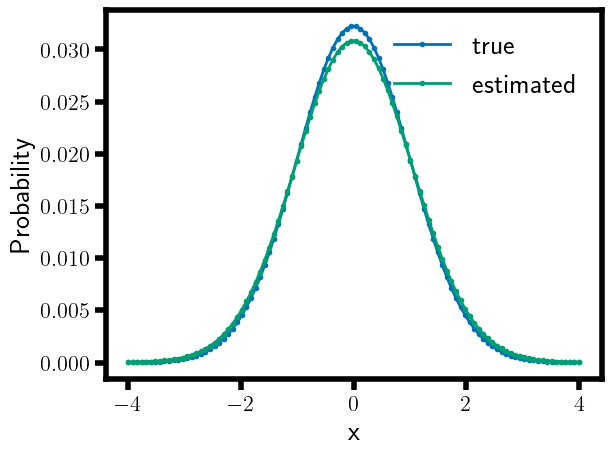

In [8]:
plt.plot(nodes, true_weights, label='true', color="C0", marker='.')
plt.plot(nodes, ensemble_weights, label='estimated', color="C1", marker='.')
plt.xlabel('x')
plt.ylabel('Probability') 
plt.legend(loc="upper right")
#plt.savefig(f"{fig_dir}/weight_comparison.png", dpi=300)



# Check Info from iterations
Note: by default, the method does not save weights, so this field shouldn't have anything except the initial weights.

In [11]:
for key in info.keys():
    print(key)
print(info["losses"].shape)
print(f"number of weights saved: {len(info["weights"])}")
print(f"total number of iterations: {info["final_idx"]}")
original_num_iterations = info['final_idx']


losses
gaps
weights
final_idx
(9,)
number of weights saved: 1
total number of iterations: 8


# Plot Loss

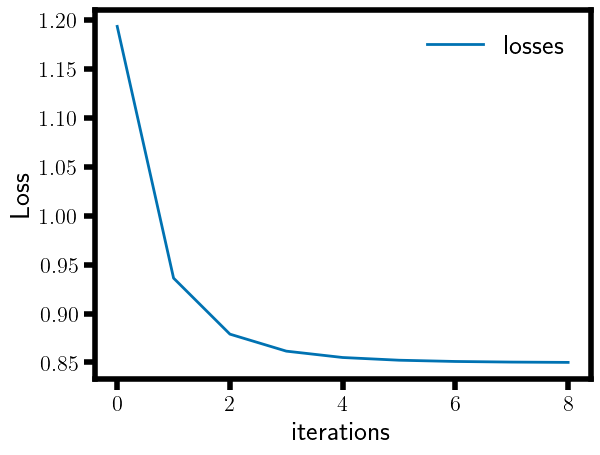

In [ ]:
losses = info["losses"]
iterations = np.arange(0, len(losses))
plt.plot(iterations, losses, label='losses')
plt.xlabel('iterations')
plt.ylabel('Loss') 
plt.legend()
#plt.savefig(f"{fig_dir}/weight_comparison.png", dpi=300)



# Lets try this again, but running for a set number of iterations

In [15]:
# Using all default info
ensemble_weights, info = multiplicative_gradient(log_likelihood, tol=-1, max_iterations=1000)
losses = info["losses"]
gaps = info["gaps"]
iterations = np.arange(0, len(losses))

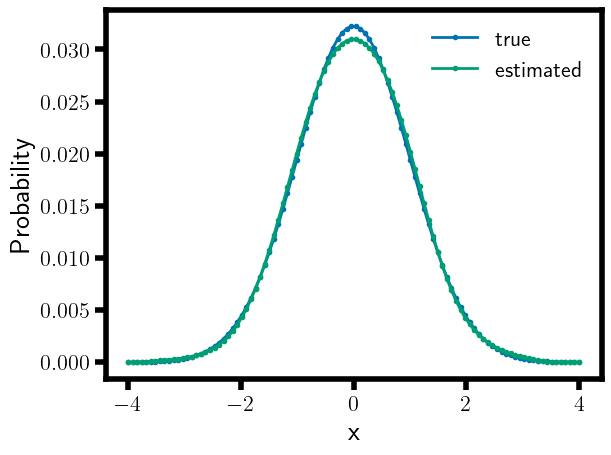

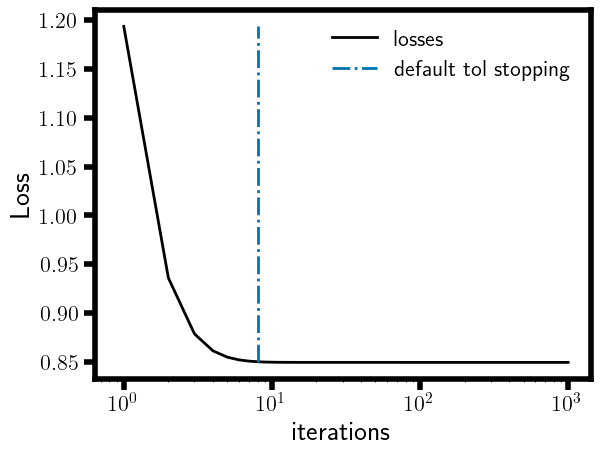

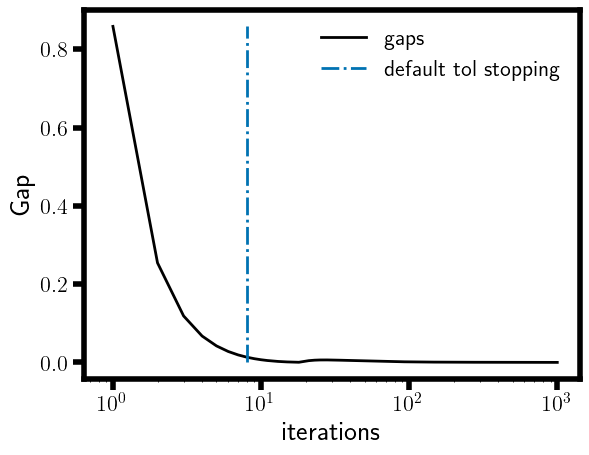

In [ ]:
# Plot final weights
plt.figure()
plt.plot(nodes, true_weights, label='true', color="C0", marker='.')
plt.plot(nodes, ensemble_weights, label='estimated', color="C1", marker='.')
plt.xlabel('x')
plt.ylabel('Probability') 
plt.legend(loc="upper right", fontsize=16)
#plt.savefig(f"{fig_dir}/weight_comparison.png", dpi=300)

# Plot losses
plt.figure()
# Here plotting a semilog plot, and shifting indices so 0 doesn't show up
plt.semilogx(iterations+1, losses, label='losses', c='k')
plt.vlines(original_num_iterations, ymin=jnp.min(losses), ymax=jnp.max(losses), colors='C0', linestyles="-.", label="default tol stopping")
plt.xlabel('iterations')
plt.ylabel('Loss') 
plt.legend(fontsize=16)
#plt.savefig(f"{fig_dir}/weight_comparison.png", dpi=300)

# Plot gaps
plt.figure()
# Here plotting a semilog plot, and shifting indices so 0 doesn't show up
plt.semilogx(iterations+1, gaps, label='gaps', c='k')
plt.vlines(original_num_iterations, ymin=jnp.min(gaps), ymax=jnp.max(gaps), colors='C0', linestyles="-.", label="default tol stopping")
plt.xlabel('iterations')
plt.ylabel('Gap') 
plt.legend(fontsize=16)
#plt.savefig(f"{fig_dir}/weight_comparison.png", dpi=300)
